# Linear regression model for house price prediction


### Imports

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
house_data = pd.read_csv('houses.csv')

In [3]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       999 non-null    float64
 1   bathrooms      999 non-null    float64
 2   sqft_living    999 non-null    float64
 3   sqft_lot       999 non-null    float64
 4   floors         999 non-null    float64
 5   waterfront     999 non-null    float64
 6   view           999 non-null    float64
 7   condition      999 non-null    float64
 8   grade          999 non-null    float64
 9   sqft_above     999 non-null    float64
 10  sqft_basement  999 non-null    float64
 11  yr_built       999 non-null    float64
 12  yr_renovated   999 non-null    float64
 13  zipcode        999 non-null    float64
 14  lat            999 non-null    float64
 15  long           999 non-null    float64
 16  sqft_living15  999 non-null    float64
 17  price          999 non-null    float64
dtypes: float6

In [4]:
house_data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,1955.0,0.0,98178.0,47.5112,-122.257,1340.0,22.19
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,98125.0,47.7210,-122.319,1690.0,53.80
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,1933.0,0.0,98028.0,47.7379,-122.233,2720.0,18.00
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,1965.0,0.0,98136.0,47.5208,-122.393,1360.0,60.40
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,1987.0,0.0,98074.0,47.6168,-122.045,1800.0,51.00


In [5]:
house_data['house_age'] = 2026 - house_data['yr_built']
house_data['renovation_age'] = np.where(house_data['yr_renovated'] > 0, 2026 - house_data['yr_renovated'], 0)

In [6]:
house_data.drop(columns = ['yr_built','yr_renovated'], inplace = True)

In [7]:
house_data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,price,house_age,renovation_age
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,98178.0,47.5112,-122.257,1340.0,22.19,71.0,0.0
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,98125.0,47.7210,-122.319,1690.0,53.80,75.0,35.0
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,98028.0,47.7379,-122.233,2720.0,18.00,93.0,0.0
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,98136.0,47.5208,-122.393,1360.0,60.40,61.0,0.0
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,98074.0,47.6168,-122.045,1800.0,51.00,39.0,0.0


In [8]:
house_data_clean = house_data.dropna()

In [9]:
house_data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 998
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bedrooms        999 non-null    float64
 1   bathrooms       999 non-null    float64
 2   sqft_living     999 non-null    float64
 3   sqft_lot        999 non-null    float64
 4   floors          999 non-null    float64
 5   waterfront      999 non-null    float64
 6   view            999 non-null    float64
 7   condition       999 non-null    float64
 8   grade           999 non-null    float64
 9   sqft_above      999 non-null    float64
 10  sqft_basement   999 non-null    float64
 11  zipcode         999 non-null    float64
 12  lat             999 non-null    float64
 13  long            999 non-null    float64
 14  sqft_living15   999 non-null    float64
 15  price           999 non-null    float64
 16  house_age       999 non-null    float64
 17  renovation_age  999 non-null    float64


In [10]:
house_data_clean.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,price,house_age,renovation_age
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,98178.0,47.5112,-122.257,1340.0,22.19,71.0,0.0
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,98125.0,47.7210,-122.319,1690.0,53.80,75.0,35.0
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,98028.0,47.7379,-122.233,2720.0,18.00,93.0,0.0
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,98136.0,47.5208,-122.393,1360.0,60.40,61.0,0.0
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,98074.0,47.6168,-122.045,1800.0,51.00,39.0,0.0


In [ ]:
ss = StandardScaler

house_data_scaled = ss.fit_transform(house_data_clean)

In [ ]:
data = pd.DataFrame(house_data_scaled, columns = house_data.columns, index = house_data.index)

In [11]:
X = house_data_clean.drop(columns = ['price'])
Y = house_data_clean['price']

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)

In [13]:
Y_train_log = np.log1p(Y_train)
Y_test_log = np.log1p(Y_test)

In [14]:
model = linear_model.LinearRegression()

In [16]:
sl = StandardScaler()

X_train_scaled_array = sl.fit_transform(X_train)
X_test_scaled_array = sl.fit_transform(X_test)


In [19]:
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns =X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns = X_test.columns, index = X_test.index)


In [20]:
model.fit(X_train_scaled, Y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
Y_pred = model.predict(X_test_scaled)

In [22]:
Y_test_normal = np.expm1(Y_test_log)
Y_pred_normal = np.expm1(Y_pred)

In [23]:
print("coef",model.coef_)
print("intercept",model.intercept_)
print("r2_score",r2_score(Y_pred_normal, Y_test_normal))
print("mean_squared_error",mean_squared_error(Y_pred_normal, Y_test_normal))

coef [ 4.55940114e-03  4.33159703e-02  5.11456479e-02  7.76345553e-05
  4.10971381e-02  4.55806628e-02  5.35734944e-02  3.35796316e-02
  1.53530818e-01  3.75112572e-02  3.57080013e-02 -3.10406811e-02
  1.98974096e-01 -1.63795475e-02  9.85006780e-02  1.09524151e-01
  1.55296199e-02]
intercept 3.837069651087357
r2_score 0.6523360446669708
mean_squared_error 273.62690771321365


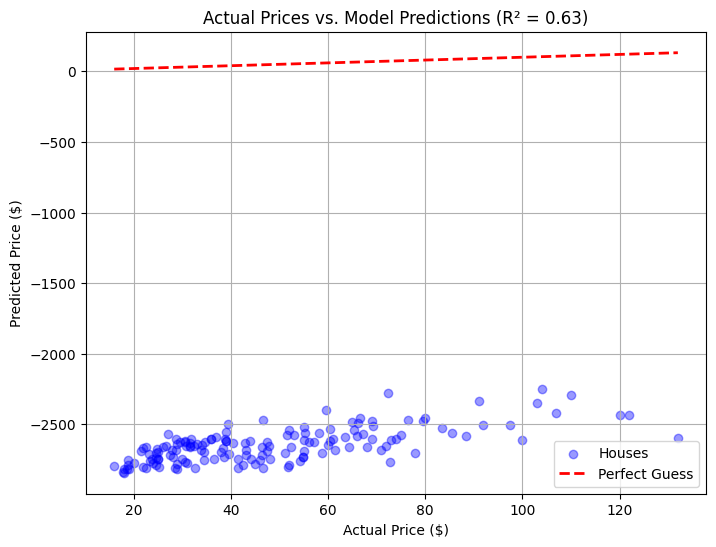

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, model.predict(X_test), alpha=0.4, color='blue', label='Houses')

plt.plot([Y_test_normal.min(), Y_test_normal.max()], [Y_test_normal.min(), Y_test_normal.max()], color='red', linestyle='--', linewidth=2, label='Perfect Guess')

#label
plt.title('Actual Prices vs. Model Predictions (R² = 0.63)')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()